## Machine Learning : Theory and Applications (2025/26)
Simona Cocco & Vito Dichio

# Tutorial 1 (START)

**Topic:** Poisson processes, Bayesian inference, and spike trains  

**Goals:**  
1) simulate Poisson spike trains;  
2) compute the posterior for rate under a simple prior;  
3) compare model vs data.

### Setup

In [16]:
# Import the necessary packages
import matplotlib.pyplot as plt
import numpy as np 
import scipy.stats as stats
from scipy.stats import poisson
from scipy.special import loggamma
import seaborn as sns
from scipy.integrate import quad

# Set a seed for reproducibility
SEED = 42
rng = np.random.default_rng(SEED)

## Part A — Simulated data
In a homogeneous Poisson process with rate $\theta$ (spikes/s), the spike count in a window of length $T$ is
$$
\Pr[X=k] = \frac{(\theta T)^k e^{-\theta T}}{k!}, \quad k=0,1,2,\dots
$$

**Question A1:** Simulate a Poisson process with rate $\theta=0.5$, and different observation times $T=10, 100, 1000$. Plot the spike times for each $T$.

[5 2 9 7 3 6 6 4 3 3]


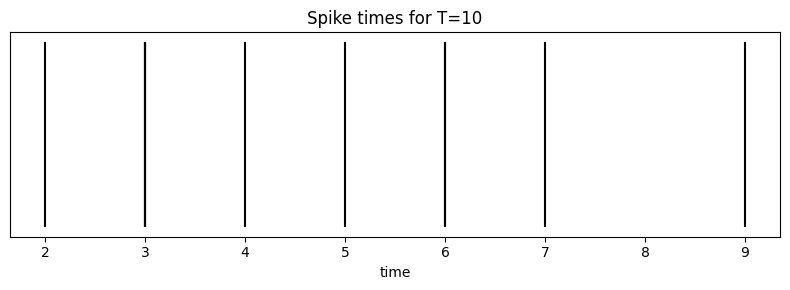

[51 58 58 55 58 50 50 51 63 52 50 45 58 52 38 47 41 37 53 58 53 54 42 76
 53 60 58 46 48 47 49 44 47 59 41 55 47 48 49 49 59 67 47 57 48 58 48 45
 34 62 46 36 47 53 66 50 63 42 43 41 56 49 69 70 47 55 52 55 60 58 46 46
 54 47 61 59 47 34 42 67 39 40 43 42 52 64 42 50 55 38 43 45 50 50 53 62
 39 48 50 56]


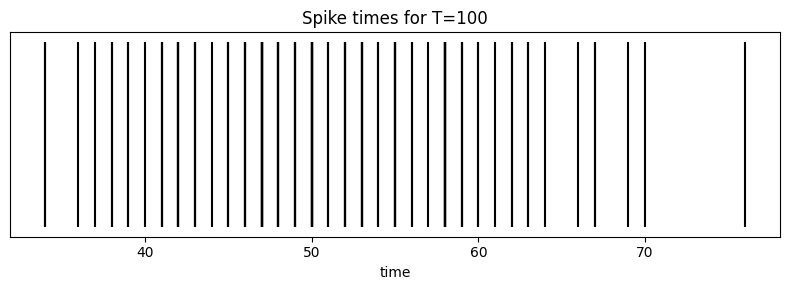

[491 496 479 529 505 467 498 535 465 503 509 489 516 495 494 499 502 485
 501 516 504 503 481 509 498 470 494 486 526 555 464 486 498 498 532 491
 550 482 465 521 511 524 492 533 506 450 506 527 537 457 498 505 463 481
 509 495 468 511 497 499 499 473 482 487 470 527 500 490 468 490 511 522
 532 507 528 506 450 481 508 476 516 519 510 499 538 521 503 483 488 508
 466 470 521 510 458 483 489 518 477 536 483 473 520 509 486 475 501 490
 479 529 493 495 504 481 487 536 498 504 476 484 513 524 484 512 520 490
 503 525 515 478 538 491 494 508 483 500 489 503 495 498 498 474 479 518
 478 475 500 502 514 546 519 501 522 500 486 488 493 490 501 522 497 495
 521 475 524 501 486 561 489 520 495 498 508 505 524 493 497 496 508 486
 509 493 504 544 494 477 477 509 509 524 492 521 491 480 513 507 492 460
 530 526 458 514 489 463 483 503 501 482 495 506 496 481 496 462 515 493
 522 492 509 496 513 484 521 472 481 480 484 480 519 483 527 500 500 477
 497 490 505 528 484 462 498 462 468 499 464 491 50

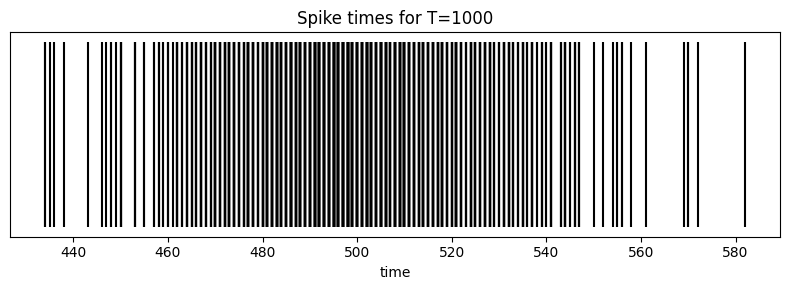

In [ ]:
# WRONG CODE !! 
# Set rate of the poisson process (obs: mean = theta*T)
theta = 0.5
T_array = [10,100,1000]
counts = np.zeros(3)
for i, T in enumerate(T_array):
    mu = theta*T
    spikes = stats.poisson.rvs(mu, size=T)
    counts[i] = stats.poisson.rvs(mu)
    # Plot a raster: each spike is a vertical line at 'folded' time,
    # placed on the row of its repetition number.
    plt.figure(figsize=(8, 3))
    plt.vlines(spikes, 0, 1, color = 'k')
    plt.xlabel("time")
    plt.title(f"Spike times for T={T}")
    # Remove y-axis ticks and labels for clarity
    plt.tick_params(left=False, labelleft=False)
    plt.tight_layout()
    plt.show()

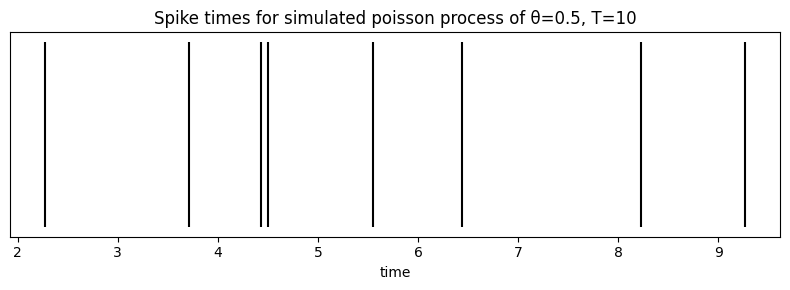

Spike count N=8


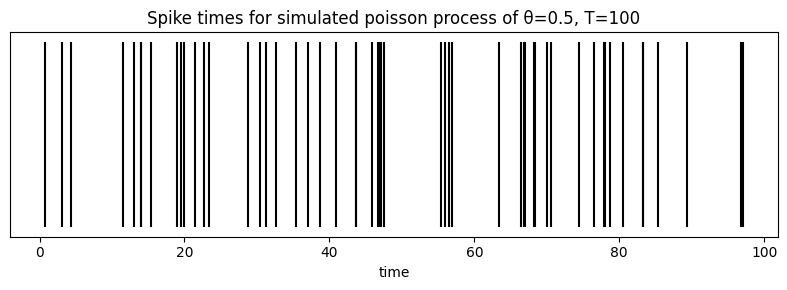

Spike count N=53


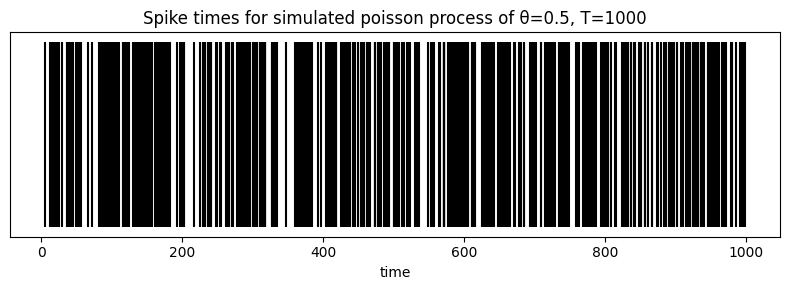

Spike count N=454


In [3]:
# Set rate of the Poisson process
theta = 0.5
num_comp = 100
T_array = np.array([10,100,1000])
counts = np.zeros(T_array.size)

for i, T in enumerate(T_array):
    # Sample number of events
    N = poisson.rvs(theta * T, random_state = rng)
    counts[i] = N
    
    # Compute spike times
    spikes = np.sort(rng.uniform(0, T, size=N))
    
    # Plot a raster: each spike is a vertical line at 'folded' time,
    # placed on the row of its repetition number.
    plt.figure(figsize=(8, 3))
    plt.vlines(spikes, 0, 1, color = 'k')
    plt.xlabel("time")
    plt.title(f"Spike times for simulated poisson process of θ={theta}, T={T}")
    # Remove y-axis ticks and labels for clarity
    plt.tick_params(left=False, labelleft=False)
    plt.tight_layout()
    plt.show()

    print(f"Spike count N={N}")

**Question A2.** From the observed counts (not spike times), compute the posterior distribution of the rate parameter $\theta$.  
Assume a uniform prior on $\theta>0$.

Our "data" is the spike count y in [0, T]. A random variable Y takes values of y associated with probabilities distributed according to a homogeneous Poisson process with constant rate $\theta$ (spikes/s) over duration T.  According to Bayes' Theorem, the formula of the posterior is:
$$p(\theta | y) = \frac{p(y| \theta) p(\theta)}{p(y)}$$
Where $p(y| \theta)$ is the likelihod, *i.e.* the probability that the data Y are generated by the model having defining parameters $\theta$; $p(\theta)$ is the prior distribution which represents our information on $\theta$ prior to any measurement; lastly, $p(y)$ is called the evidence, and is expressed in terms of the prior and of the likelihood through:
$$p(y) = \int_0^\infty P(y|\theta)P(\theta)\mathrm{d}\theta$$
Its primary role is to guarantee the normalisation of the posterior $p(\theta | y )$.

- Likelihood: 
By definition of a Poisson process, we have:
$$
p(Y=y | \theta) = \frac{(\theta T)^y e^{-\theta T}}{y!}
$$
- Pior: 
We assumed an uniform prior, so $p(y | \theta)$ = 1 for $\theta > 0$ and $p(y | \theta)$ = 0 elsewhere.
- Evidence:
By reinjecting the likelihood and prior into the expession of the evidence, we have: $$p(y) = \int_0^\infty P(y|\theta)P(\theta)\mathrm{d}\theta = \int_0^\infty \frac{(\theta T)^y e^{-\theta T}}{y!} \mathrm{d}\theta = \frac{1}{y!T}\int_0^\infty x^y e^{-x}\mathrm{d}x$$
Which we obtain by doing the variable change $x = \theta T$; $dx = Td\theta$.

Uusing $\Gamma(n+1) = n!$ for $n \in \mathbb{N}$, we end up with the expression: 
$$ p(y) = \frac{\Gamma (y+1)}{y!T} = \frac{1}{T} $$
Putting everything together, we can derive the expression of the posterior:
$$ p(\theta | y ) = \frac{\theta^y T^{y+1} e^{-\theta T}}{\Gamma (y+1)}, \quad \theta > 0 $$

In [60]:
def log_likelihood(theta: float | np.ndarray, T: float, y: int) -> float | np.ndarray:
    """Compute the log-likelihood of observing y spikes in time T given firing rate theta.

    Parameters
    ----------
    theta : float
        Firing rate (spikes per unit time).
    T : float
        Observation time window.
    y : int
        Observed spike count.

    Returns
    -------
    log_likelihood : float
        Log-likelihood of observing y spikes in time T given theta.
    """
    log_likelihood = y * np.log(theta * T) - (theta * T) - loggamma(y + 1)
    return log_likelihood

def uniform_prior(theta: float | np.ndarray) -> float | np.ndarray:
    """Compute the prior distribution of the rate parameter theta.

    Parameters
    ----------
    theta : float
        Firing rate (spikes per unit time).

    Returns
    -------
    prior : float
        Uniform prior (= 1 for theta > 0, 0 otherwise).
    """
    prior = np.asarray((theta > 0), dtype=int)
    return prior
    
def posterior(theta: float | np.ndarray, T: float, y: int) -> float | np.ndarray:
    """Compute the posterior distribution of the rate parameret theta.

    Parameters
    ----------
    theta : float or np.ndarray
        Firing rate (spikes per unit time).

    Returns
    -------
    posterior : float or np.ndarray
        Unnormalized posterior value at theta.
    """
    posterior = T*np.exp(log_likelihood(theta, T, y))*uniform_prior(theta)
    return posterior

C:\Users\Bruna\AppData\Local\Temp\ipykernel_3344\1524498421.py:18: RuntimeWarning: divide by zero encountered in log
  log_likelihood = y * np.log(theta * T) - (theta * T) - loggamma(y + 1)


<function matplotlib.pyplot.show(close=None, block=None)>

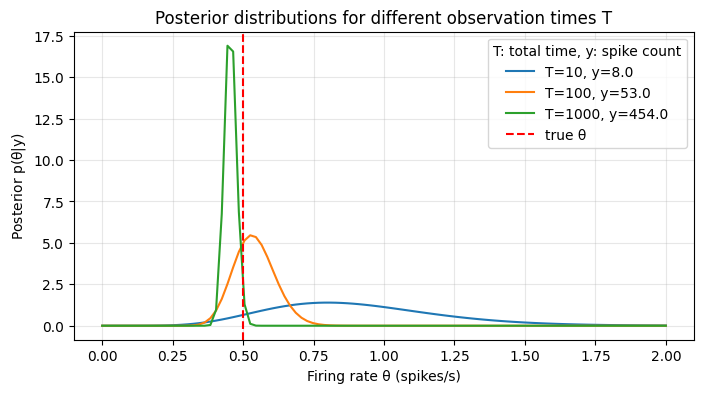

In [30]:
# Define range of theta values for computing posterior
theta_vals = np.linspace(0, 2, num=100)

# Set up figure
fig, ax = plt.subplots(figsize=(8, 4))

for T, spikes in zip(T_array, counts):
    # Compute posterior for range of theta values
    posterior_distribution = [posterior(theta, T, spikes) for theta in theta_vals]
    # Plot
    ax.plot(theta_vals, posterior_distribution, label=f"T={T}, y={spikes}")
    # Draw a vertical line at the true rate for reference

ax.axvline(theta, color="red", ls="--", label="true θ") 
ax.set_xlabel("Firing rate θ (spikes/s)")
ax.set_ylabel(r"Posterior $p(\theta | y)$")
ax.set_title("Posterior distributions for different observation times T")
ax.grid(alpha=0.3)   
ax.legend(title = "T: total time, y: spike count")
plt.show

**Question A3.** Compute **(i)** the posterior mean estimator, **(ii)** the Maximum Likelihood Estimator (MLE), and **(iii)** the estimator variance.

Cf my handwritten notes

In [40]:
def estimators_for_count(y, T):
    """
    Given count y over duration T:
      - Posterior: Gamma(shape = y+1, rate = T)  → scale = 1/T
      - Posterior mean: (y+1)/T
      - MLE: y/T
      - Posterior variance: (y+1)/T^2
    """
    theta_mean = (y + 1) / T
    theta_mle  = y / T
    var_theta  = (y + 1) / (T**2)
    return theta_mean, theta_mle, var_theta

print("Estimators (posterior mean, MLE) and posterior variance")
print("-" * 65)
for T, y in zip(T_array, counts):
    theta_mean, theta_mle, var_theta = estimators_for_count(y, T)

    print(f"T={T:>5} | y={y:>4} | "
          f"mean={(theta_mean):.2e} | MLE={(theta_mle):.2e} | var={(var_theta):.2e} ")

Estimators (posterior mean, MLE) and posterior variance
-----------------------------------------------------------------
T=   10 | y= 6.0 | mean=7.00e-01 | MLE=6.00e-01 | var=7.00e-02 
T=  100 | y=45.0 | mean=4.60e-01 | MLE=4.50e-01 | var=4.60e-03 
T= 1000 | y=525.0 | mean=5.26e-01 | MLE=5.25e-01 | var=5.26e-04 


## Part B — Experimental data
We’ll load spike times for 40 retinal ganglion cells responding to a repeated natural movie (duration per repeat **stim_t = 26.5 s**; repeated ~120 times).

Data from [Schneidman et al., 2006 — *Weak pairwise correlations imply strongly correlated network states in a neural population*, Nature](https://www.nature.com/articles/nature04701)</small>


In [31]:
# length (in seconds) of periodic stimulus
stim_t = 26.5

### Loading the spike data

The file `dati2-berry.dat` contains the spike times (in seconds) of **40 retinal ganglion cells** recorded during repeated presentation of a natural movie.  
- The file is a **one-column array** of spike times, concatenated across neurons.  
- Each neuron’s block of spikes is preceded by the marker value **4000**, followed by the **neuron ID**.  
- After these two entries, the subsequent numbers are the actual spike times (in seconds) for that neuron.  

In [32]:
# load data
data = np.loadtxt('data/dati2-berry.dat')
data

array([4.00000000e+03, 4.00000000e+00, 2.08000004e-01, ...,
       3.17675360e+03, 3.17903420e+03, 3.17946570e+03])

In [33]:
# Each block looks like: [4000, neuron_id, spike_t1, spike_t2, ...].

# Split at every 4000 (skip the very first to avoid an empty block)
datas = np.split(data, np.where(data == 4000)[0][1:])

# Drop the marker (4000) and neuron ID, keep only spike times
datas = [d[2:] for d in datas]

print(f"Loaded {len(datas)} neurons.")

Loaded 40 neurons.


#neurons: 40
Neuron 0: #spikes=12824, max time=3179.37s


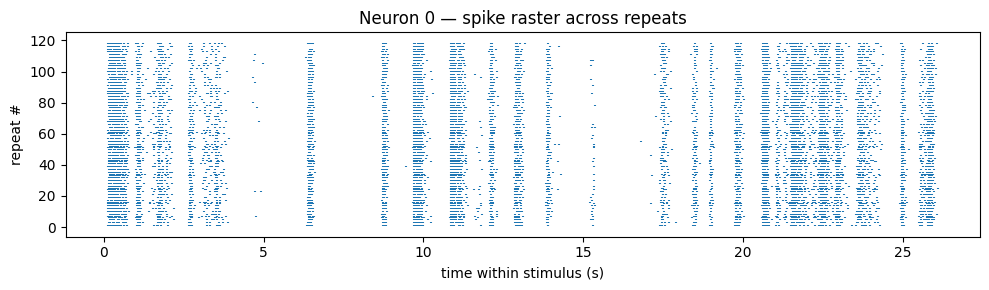

In [34]:
### Quick sanity checks and a first plot

if datas is not None:
    n_neurons = len(datas)

    # First neuron spikes
    spikes0 = np.asarray(datas[0], dtype=float)

    print(f"#neurons: {n_neurons}")
    print(f"Neuron 0: #spikes={spikes0.size}, max time={spikes0.max():.2f}s")

    # Raster within a single stimulus window (folded mod stim_t)
    plt.figure(figsize=(10, 3))
    
    # Fold spike times into the stimulus cycle:
    folded = spikes0 % stim_t       # position of each spike within one 26.5s repeat
    reps   = (spikes0 // stim_t).astype(int)  # which repetition the spike belongs to
    
    # Plot a raster: each spike is a vertical line at 'folded' time,
    # placed on the row of its repetition number.
    plt.vlines(folded, reps - 0.2, reps + 0.2)

    plt.xlabel("time within stimulus (s)")
    plt.ylabel("repeat #")
    plt.title("Neuron 0 — spike raster across repeats")
    plt.tight_layout()
    plt.show()

**Question B1.** Assuming a homogeneous Poisson process over the whole recording for neuron 0, infer its spiking rate. Specifically:  
**(i)** compute and plot the posterior $P(\theta \mid y)$ under the same Uniform($\theta\ge0$) prior;  
**(ii)** compute the posterior mean, variance, and MLE.

<function matplotlib.pyplot.show(close=None, block=None)>

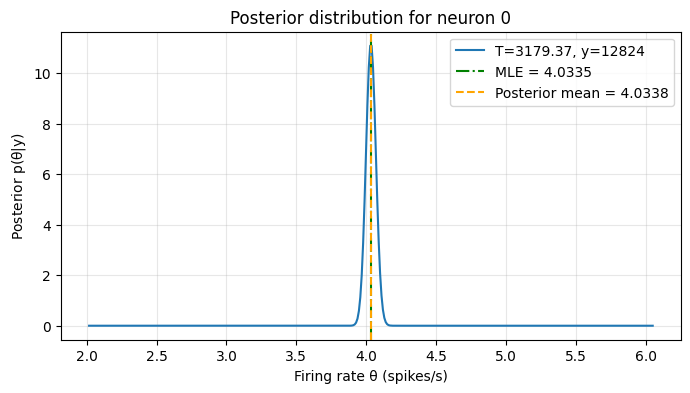

In [75]:
# B1
# Define spike count and total observation time from data of neuron 0
y0 = len(spikes0)
T = spikes0.max()

# Range of theta for plotting posterior
theta_vals = np.linspace(0.5*(y0 / T), 1.5 * (y0 / T), 400)

# Compute posterior for range of theta values
posterior_distribution = posterior(theta=theta_vals, T=T, y=y0)
# Estimators
theta_mean, theta_mle, theta_var = estimators_for_count(y0, T)

# Set up figure
fig, ax = plt.subplots(figsize=(8, 4))
# Plot
ax.plot(theta_vals, posterior_distribution, label=f"T={T:.2f}, y={y0:.0f}")
ax.axvline(theta_mle, color="green", ls="-.", label=f"MLE = {theta_mle:.4f}")
ax.axvline(theta_mean, color="orange", ls="--", label=f"Posterior mean = {theta_mean:.4f}")
# Draw a vertical line at the true rate for reference
ax.set_xlabel("Firing rate θ (spikes/s)")
ax.set_ylabel(r"Posterior $p(\theta | y)$")
ax.set_title("Posterior distribution for neuron 0")
ax.grid(alpha=0.3)   
ax.legend()
plt.show

**Question B2.** Simulate a Poisson process using your posterior mean rate for neuron 0 over the same duration **T**.  
Compare:
- raster **within a single stimulus window** (use modulo `stim_t`),  
- **inter-spike interval** distributions (data vs simulation).

**Bonus:** overlay the theoretical exponential inter-spike interval ISI density $ f(\Delta t) = \theta e^{-\theta \Delta t} $.

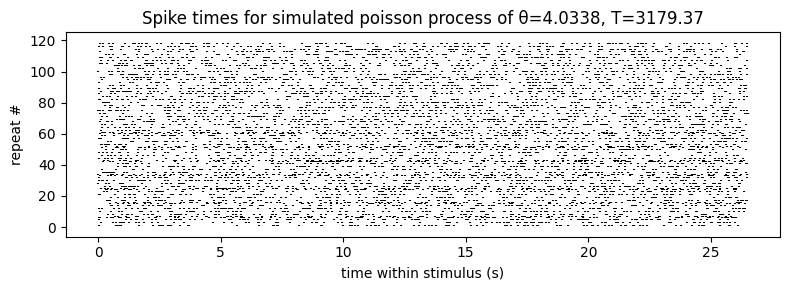

In [81]:
# Sample number of events
N = poisson.rvs(theta_mean * T, random_state = rng)

# Compute spike times
spikes = np.sort(rng.uniform(0, T, size=N))

# Fold spike times into the stimulus cycle:
folded_sim = spikes % stim_t       # position of each spike within one 26.5s repeat
reps_sim   = (spikes // stim_t).astype(int)  # which repetition the spike belongs to

# Plot a raster: each spike is a vertical line at 'folded' time,
# placed on the row of its repetition number.
plt.figure(figsize=(8, 3))
plt.vlines(folded_sim, reps_sim - 0.2, reps_sim + 0.2, color = 'k')
plt.xlabel("time within stimulus (s)")
plt.ylabel("repeat #")
plt.title(f"Spike times for simulated poisson process of θ={theta_mean:.4f}, T={T:.2f}")
plt.tight_layout()
plt.show()

In [ ]:
# using this assumption, compute the posterior 

# posterior = prior * likelihood / evidence
# here, prior is uniform

# simulate a poisson process 

We see that the process seems to not be correctly simulated by a Poisson process, it's a more complex statistical process than only a Poisson one.

# Optional tasks

**Question C1** (Theory): Prove that if the event rate is constant $\theta$, then the number of events $N(T)$ observed in a time window of duration $T$ follows a Poisson distribution with mean $\theta T$:
$$
\Pr[N(T)=k] = e^{-\theta T}\,\frac{(\theta T)^k}{k!}, \quad k=0,1,2,\dots
$$

**Bibliography:**
From Statistical Physics to Data-Driven Modelling: with Applications to Quantitative Biology (1st Edition), by Simona Cocco, Rémi Monasson, Francesco Zamponi -- 2022